# Para este ejercicio independiente se entrega al grader un mejor contexto o como debe ser una buena solución. 
La siguiente imagen es tomada del curso oficial:
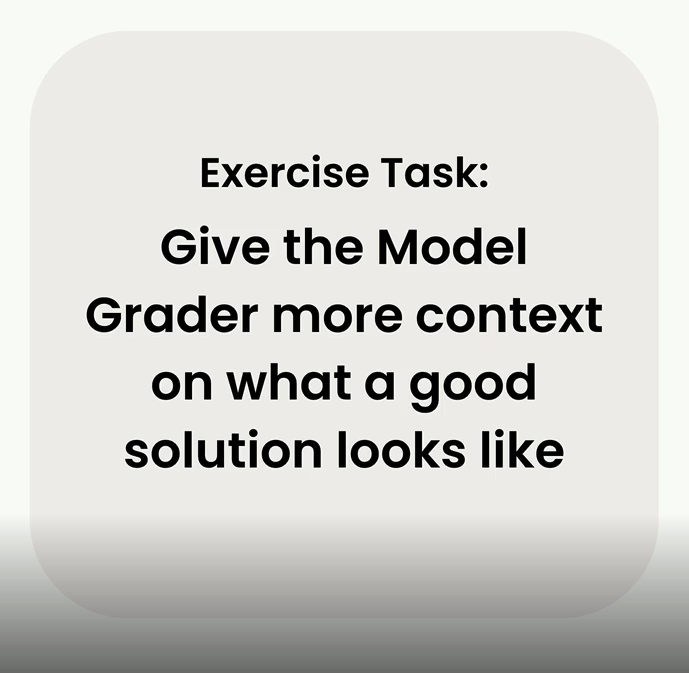

# El objetivo será:
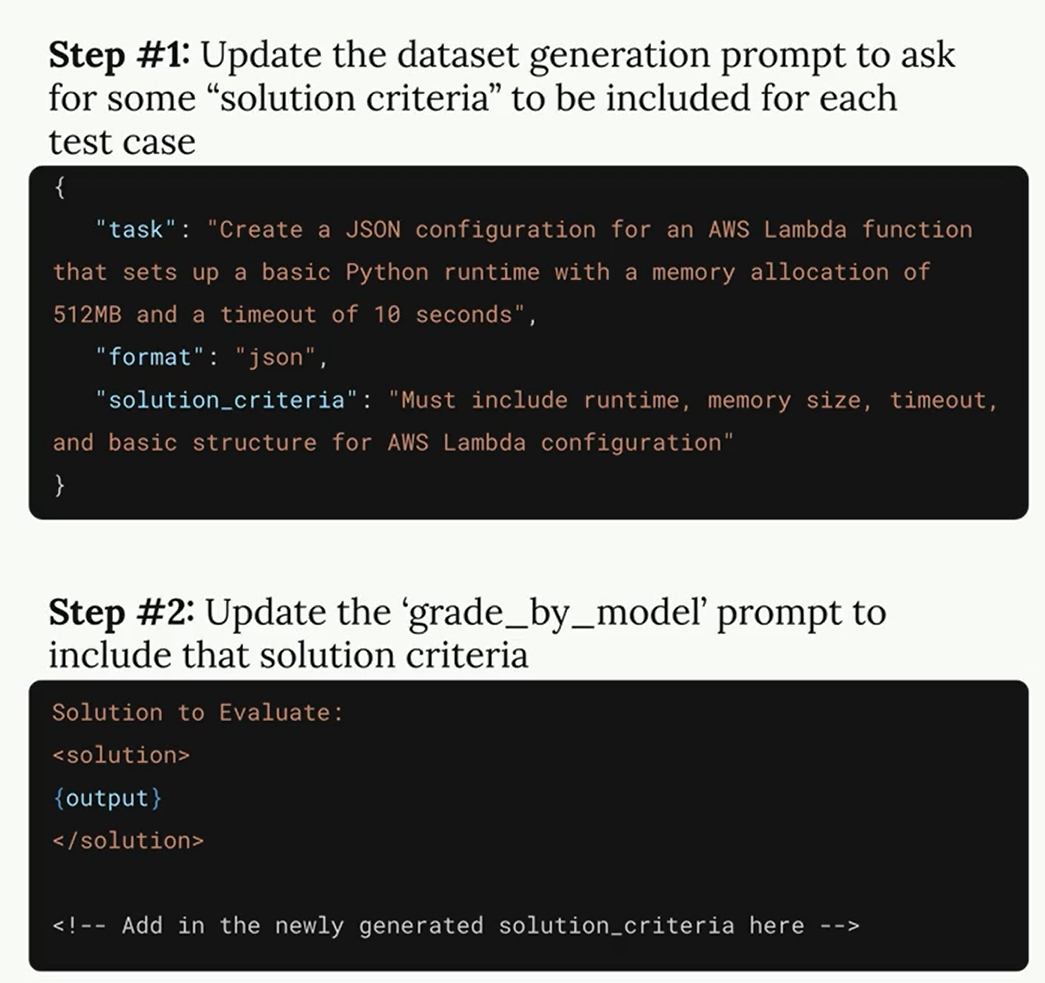



In [7]:
# Install dependencies
%pip install anthropic python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Load Variables
from dotenv import load_dotenv

load_dotenv()

True

In [9]:
# Create an API Client
from anthropic import Anthropic
import os

client = Anthropic()
model = "claude-sonnet-4-5"

In [10]:
# Funciones auxiliares
from os import system

def add_user_message(messages, user_input):
    messages.append({"role": "user", "content": user_input})

def add_assistant_message(messages, answer):
    messages.append({"role": "assistant", "content": answer})

def chat(messages, system=None, temperature=1.0, stop_sequences=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature
    }
    if system:
        params["system"] = system
    if stop_sequences:
        params["stop_sequences"] = stop_sequences

    response = client.messages.create(**params)
    return response.content[0].text

# Solución:
En la función generate_dataset() se debe ajustar tanto el prompt como el ejemplo de la salida.

**Original:**
prompt = """
Generate an evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects, each representing task that requires Python, JSON, or a Regex to complete. 

Example output:
```json
[
    "task": "Description of task",
    "format": "JSON" or "Python" or "Regex"
    
},
...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a single regex
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""

**Actualizado:**
prompt = """
Generate an evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects, each representing task that requires Python, JSON, or a Regex to complete. **Also include some solution criteria for each task, such as the expected output or the expected behavior of the code.**

Example output:
```json
[
    "task": "Description of task",
    "format": "JSON" or "Python" or "Regex",
    "solution_criteria": "Description of the expected output or behavior"
},
...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a single regex
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""

Observe que de esta parte el texto en negrilla es nuevo. Además el bloque del ejemplo del formato de salida incluye una nueva parte al final **"solution_criteria": "Description of the expected output or behavior"**

In [11]:
# Generar dataset
import json

def generate_dataset():
    prompt = """
Generate an evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects, each representing task that requires Python, JSON, or a Regex to complete. Also include some solution criteria for each task, such as the expected output or the expected behavior of the code.

Example output:
```json
[
    "task": "Description of task",
    "format": "JSON" or "Python" or "Regex",
    "solution_criteria": "Description of the expected output or behavior"
},
...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a single regex
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""

    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages, "```json")
    text=chat(messages, temperature=0.7, stop_sequences=["```"])
    return json.loads(text)

In [12]:
dataset = generate_dataset()
with open("dataset.json", "w") as f:
    json.dump(dataset, f, indent=2)
#Imprimir el dataset generado si quiero verlo
# print(json.dumps(dataset, indent=2))

In [13]:
#Toma cada uno de los task que estan en el dataset.json (son los test cases)
def run_prompt(test_case):
     """Merges the prompt and test case input, the reutrns the results"""
     prompt=f"""
Please solve the following task: 

{test_case['task']}

*Respond only with the {test_case['format']} without any explanation or additional text.*
"""
     messages = []
     add_user_message(messages, prompt)
     add_assistant_message(messages, "```code")  
     answer=chat(messages, stop_sequences=["```"], temperature=0.7)
     return answer

Ahora se procede a actualizar la función grade_by_model(test_case,answer) para incluir el solution criteria

In [14]:
def grade_by_model(test_case, answer):
    # Create evaluation prompt
    eval_prompt = f"""
    You are an expert AWS code reviewer. Your task is to evaluate the following AI-generated solution. Include the solution criteria in your evaluation. Be critical but fair in your assessment, and provide constructive feedback.
    
    Original Task:
    <task>
    {test_case["task"]}
    </task>

    Solution to Evaluate:
    <solution>
    {answer}
    </solution>

    Solution Criteria:
    <criteria>
    {test_case["solution_criteria"]}
    </criteria>
   
    Output Format:
    Provide your evaluation as a structured JSON object with the following fields:
    - "strengths": An array of 1-3 key strengths
    - "weaknesses": An array of 1-3 key areas for improvement  
    - "reasoning": A concise explanation of your assessment
    - "score": A number between 1-10
   
    Respond with JSON. Keep your response concise and direct.
    Example response shape:
    {{
    "strengths": string [],
    "weaknesses": string [], 
    "reasoning": string,
    "score": number
    }}
    """
    
    messages = []
    add_user_message(messages, eval_prompt)
    add_assistant_message(messages, "```json")
    
    eval_text = chat(messages, stop_sequences=["```"])
    return json.loads(eval_text)

In [15]:

import ast
import re

def validate_json(text):
    try:
        json.loads(text.strip())
        return 10
    except json.JSONDecodeError:
        return 0

def validate_python(text):
    try:
        ast.parse(text.strip())
        return 10
    except SyntaxError:
        return 0

def validate_regex(text):
    try:
        re.compile(text.strip())
        return 10
    except re.error:
        return 0
    
def grade_syntax(response, test_case):
    format=test_case["format"]
    if format=="JSON":
        return validate_json(response)
    elif format=="Python":
        return validate_python(response)
    elif format=="Regex":
        return validate_regex(response)
    else:
        raise ValueError(f"Unknown format: {format}")

In [16]:
#
def run_test_case(test_case):
    """Calls run_prompt, the grades the results"""
    answer=run_prompt(test_case)

    #Grading prompt para evaluar la respuesta y asignarle una calificacion
    model_grade=grade_by_model(test_case, answer)
    model_score=model_grade["score"]
    reasoning =model_grade["reasoning"]
    
    syntax_score=grade_syntax(answer, test_case)
    score=(model_score + syntax_score) / 2
 
    return {
        "answer": answer,
        "test_case": test_case,
        "score": score,
        "reasoning": reasoning
    }

In [17]:
from statistics import mean

def run_eval(dataset):
    """Loads the dataset and calls run_test_case with each test case""" 
    results = []
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)

    average_score = mean(result["score"] for result in results)
    print(f"Average Score: {average_score}")
    return results

In [18]:
with open("dataset.json", "r") as f:
    dataset = json.load(f)

results = run_eval(dataset)

Average Score: 8.166666666666666


In [19]:
print(json.dumps(results, indent=2))

[
  {
    "answer": "\n{\n  \"Version\": \"2012-10-17\",\n  \"Statement\": [\n    {\n      \"Effect\": \"Allow\",\n      \"Action\": [\n        \"s3:GetObject\",\n        \"s3:GetObjectVersion\",\n        \"s3:ListBucket\",\n        \"s3:GetBucketLocation\"\n      ],\n      \"Resource\": [\n        \"arn:aws:s3:::company-logs-2024\",\n        \"arn:aws:s3:::company-logs-2024/*\"\n      ]\n    }\n  ]\n}\n",
    "test_case": {
      "task": "Create an IAM policy that allows read-only access to a specific S3 bucket named 'company-logs-2024' and all objects within it",
      "format": "JSON",
      "solution_criteria": "JSON policy document with Version '2012-10-17', Effect 'Allow', Action containing s3:GetObject and s3:ListBucket, and Resource ARNs for the bucket and its objects (arn:aws:s3:::company-logs-2024 and arn:aws:s3:::company-logs-2024/*)"
    },
    "score": 9.0,
    "reasoning": "The solution meets all stated criteria and provides a functional read-only IAM policy for the speci